# 4. Causal Analysis — The Effect of COVID-19 Restrictions on Air Quality

## Research question

**Do stricter COVID-19 restrictions reduce urban air pollution in European cities?**

We exploit the cross-country and temporal variation in the Oxford Stringency Index
to estimate the causal effect of lockdown severity on city-level NO2 concentrations
using a panel fixed-effects framework.

## What this notebook does

1. **Identification strategy** — explain our research design and assumptions
2. **Model specifications** — estimate progressively richer FE models
3. **Event study** — visualize dynamic treatment effects around major lockdowns
4. **Robustness checks** — alternative outcomes, leave-Italy-out, lagged treatment
5. **Heterogeneity** — Italy-specific event study, country-level effects

## Data

We use the analysis-ready panel from notebook 3: **120 cities × ~960 days**
(Jan 2020 – Dec 2022), with daily NO2, weather controls, and the Oxford
Stringency Index at the national level.

In [1]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyfixest", "-q"])

import pandas as pd
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

import os
os.makedirs("../output/figures", exist_ok=True)
os.makedirs("../output/tables", exist_ok=True)

In [2]:
# Load analysis-ready panel from notebook 3
df = pd.read_csv('../data/clean/panel_city_day.csv')
df['date'] = pd.to_datetime(df['date'])

# Rename columns with spaces for pyfixest compatibility
df = df.rename(columns={'wind speed': 'wind_speed', 'wind gust': 'wind_gust'})

print(f'Panel: {len(df):,} rows, {df["City"].nunique()} cities, {df["Country"].nunique()} countries')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Stringency: mean={df["stringency_index"].mean():.1f}, std={df["stringency_index"].std():.1f}')
print(f'NO2: mean={df["no2"].mean():.1f}, std={df["no2"].std():.1f}')

Panel: 115,708 rows, 120 cities, 9 countries
Date range: 2020-01-02 to 2022-12-31
Stringency: mean=48.6, std=24.8
NO2: mean=8.2, std=5.4


---
## 4.1 Identification Strategy

### The challenge

A naive regression of NO2 on stringency would be biased by **confounders**:
- **Seasonality**: NO2 is highest in winter; lockdowns in spring 2020 coincided
  with the natural seasonal decline
- **City-level differences**: Some cities (especially in Italy) have permanently
  higher NO2 due to geography, vehicle fleet, or industrial mix
- **Weather**: Temperature, wind, and humidity directly affect pollutant
  concentrations and vary with the seasons

### Our design: Panel Fixed Effects

We use a **two-way fixed effects (TWFE)** regression that exploits:
- **Cross-country variation** in lockdown timing and severity (9 countries imposed
  restrictions at different times and intensities)
- **Within-city, within-week variation** after absorbing city-specific levels
  and common time shocks

### Baseline specification

$$\ln(\text{NO2})_{it} = \beta \cdot \text{Stringency}_{c(i),t} + \gamma' \mathbf{W}_{it} + \alpha_i + \delta_t + \varepsilon_{it}$$

where:
- $i$ = city, $t$ = day, $c(i)$ = country of city $i$
- $\alpha_i$ = **city fixed effects** (absorb time-invariant city characteristics:
  population, geography, industrial base, vehicle fleet)
- $\delta_t$ = **time fixed effects** (year-week: absorb common weekly shocks
  and seasonality)
- $\mathbf{W}_{it}$ = weather controls (temperature, humidity, pressure, wind speed)
- $\beta$ = our parameter of interest: the effect of a 1-unit increase in
  stringency on ln(NO2)

### Standard errors

Since our treatment (stringency) varies at the **country level**, we cluster
standard errors by country. With only 9 clusters, inference is challenging —
we report both clustered SEs and heteroskedasticity-robust SEs for comparison.

### Key assumptions

1. **Parallel trends** (conditional on FE and controls): absent COVID restrictions,
   NO2 trends would have been similar across countries. We test this with an
   event study.
2. **No anticipation**: cities did not change pollution behavior before
   restrictions were formally announced.
3. **SUTVA**: one country's restrictions don't affect another country's air quality
   (plausible — air quality is local).

---
## 4.2 Preparing variables for regression

We standardize the stringency index to make coefficients more interpretable:
a 10-point increase (roughly one policy level change) rather than a 1-point increase.

In [3]:
# Scale stringency so coefficients are per 10-point increase
df['stringency_10'] = df['stringency_index'] / 10
df['stringency_lag7_10'] = df['stringency_lag7'] / 10
df['stringency_lag14_10'] = df['stringency_lag14'] / 10
df['stringency_7d_avg_10'] = df['stringency_7d_avg'] / 10

# Day-of-week as categorical
df['dow'] = df['dow'].astype('category')

# Verify key variables
print('Key variable summary:')
for col in ['ln_no2', 'stringency_10', 'temperature', 'humidity', 'pressure', 'wind_speed']:
    n_ok = df[col].notna().sum()
    print(f'  {col:25s}  mean={df[col].mean():8.2f}  std={df[col].std():7.2f}  N={n_ok:,}')

Key variable summary:
  ln_no2                     mean=    2.08  std=   0.53  N=111,786
  stringency_10              mean=    4.86  std=   2.48  N=115,708
  temperature                mean=   13.79  std=   6.94  N=114,045
  humidity                   mean=   72.43  std=  16.31  N=113,903
  pressure                   mean= 1015.32  std=  16.60  N=114,037
  wind_speed                 mean=    2.95  std=   2.61  N=110,253


---
## 4.3 Main results — Progressive model specifications

We build up our specification step by step, following the approach from
our textbook (Bekes & Kezdi, Ch. 22–23):

| Model | Specification | Purpose |
|-------|--------------|----------|
| M1 | Pooled OLS (no FE) | Naive benchmark — expected to be biased |
| M2 | City FE only | Control for permanent city differences |
| M3 | City + year-week FE | Add common time shocks and seasonality |
| M4 | City + year-week FE + weather | Full baseline — our preferred specification |
| M5 | M4 + day-of-week FE | Check for weekday/weekend traffic patterns |
| M6 | M4 + country-specific linear trends | Address differential trending across countries |

In [4]:
# Model 1: Pooled OLS — naive benchmark (no fixed effects)
m1 = pf.feols(
    'ln_no2 ~ stringency_10',
    data=df,
    vcov='hetero'
)

# Model 2: City FE only
m2 = pf.feols(
    'ln_no2 ~ stringency_10 | City',
    data=df,
    vcov={'CRV1': 'country_name'}
)

# Model 3: City + year-week FE
m3 = pf.feols(
    'ln_no2 ~ stringency_10 | City + yearweek',
    data=df,
    vcov={'CRV1': 'country_name'}
)

# Model 4: City + year-week FE + weather controls (PREFERRED)
m4 = pf.feols(
    'ln_no2 ~ stringency_10 + temperature + humidity + pressure + wind_speed | City + yearweek',
    data=df,
    vcov={'CRV1': 'country_name'}
)

# Model 5: M4 + day-of-week FE
m5 = pf.feols(
    'ln_no2 ~ stringency_10 + temperature + humidity + pressure + wind_speed | City + yearweek + dow',
    data=df,
    vcov={'CRV1': 'country_name'}
)

# Model 6: M4 + country-specific linear time trends
# Create time trend and country interactions
df['time_trend'] = (df['date'] - df['date'].min()).dt.days
for country in df['country_name'].unique():
    df[f'trend_{country.replace(" ", "_")}'] = (
        (df['country_name'] == country).astype(int) * df['time_trend']
    )
trend_vars = [f'trend_{c.replace(" ", "_")}' for c in df['country_name'].unique()]
trend_formula = ' + '.join(trend_vars)

m6 = pf.feols(
    f'ln_no2 ~ stringency_10 + temperature + humidity + pressure + wind_speed + {trend_formula} | City + yearweek',
    data=df,
    vcov={'CRV1': 'country_name'}
)

In [5]:
# Table 1: Main results
pf.etable(
    [m1, m2, m3, m4, m5, m6],
    model_heads=['(1) Pooled OLS', '(2) City FE', '(3) City + Week FE',
                 '(4) + Weather', '(5) + Day-of-week', '(6) + Country trends'],
    head_order='h',
    labels={
        'stringency_10': 'Stringency / 10',
        'temperature': 'Temperature',
        'humidity': 'Humidity',
        'pressure': 'Pressure',
        'wind_speed': 'Wind speed',
    },
    keep=['stringency_10', 'temperature', 'humidity', 'pressure', 'wind_speed'],
    show_se_type=True,
    digits=4
)

GT(_tbl_data=   level_0               level_1                        0  \
0     coef       Stringency / 10  0.0114*** <br> (0.0007)   
1     coef           Temperature                            
2     coef              Humidity                            
3     coef              Pressure                            
4     coef            Wind speed                            
5       fe                  City                        -   
6       fe                   dow                        -   
7       fe              yearweek                        -   
8    stats          Observations                   111786   
9    stats             S.E. type                   hetero   
10   stats         R<sup>2</sup>                   0.0028   
11   stats  R<sup>2</sup> Within                        -   

                        1                      2                        3  \
0   -0.0022 <br> (0.0075)  -0.0044 <br> (0.0053)    -0.0029 <br> (0.0059)   
1                                                    0.0006 <br> (0.0030)   
2                                                  -0.0011* <br> (0.0004)   
3                                                    0.0015 <br> (0.0008)   
4                                                 -0.0575** <br> (0.0163)   
5                       x                      x                        x   
6                       -                      -                        -   
7                       -                      x                        x   
8                  111786                 111786                   106548   
9        by: country_name       by: country_name         by: country_name   
10                 0.3813                 0.5399                   0.6021   
11                 0.0002                 0.0001                   0.1256   

                          4                        5  
0     -0.0017 <br> (0.0062)    -0.0001 <br> (0.0067)  
1     -0.0009 <br> (0.0028)     0.0004 <br> (0.0029)  
2    -0.0013* <br> (0.0005)   -0.0011* <br> (0.0005)  
3      0.0014 <br> (0.0007)     0.0014 <br> (0.0007)  
4   -0.0569** <br> (0.0162)  -0.0570** <br> (0.0162)  
5                         x                        x  
6                         x                        -  
7                         x                        x  
8                    106548                   106548  
9          by: country_name         by: country_name  
10                   0.6507                   0.6267  
11                   0.1381                   0.1797  , _body=<great_tables._gt_data.Body object at 0x0000023AA14F9BE0>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023AA379B750>, _spanners=Spanners([SpannerInfo(spanner_id='(1) Pooled OLS', spanner_level=1, spanner_label='(1) Pooled OLS', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='(2) City FE', spanner_level=1, spanner_label='(2) City FE', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='(3) City + Week FE', spanner_level

**Interpretation of Table 1:**

Read the coefficient on `Stringency / 10` across columns:

- **Model 1 (pooled OLS)**: Surprisingly **positive** — cities in countries with higher
  stringency tend to have higher NO2 in the raw data. This is pure confounding: the
  countries that locked down hardest (Italy, Spain) also happen to have the highest
  baseline pollution due to geography and vehicle fleets. This illustrates exactly why
  we need fixed effects.
- **Model 2 (city FE)**: Once we absorb permanent city-level differences, the coefficient
  turns negative but is small and insignificant. Time-varying confounders (seasonality)
  still bias this estimate.
- **Model 3 (city + week FE)**: Adding year-week FE absorbs seasonality and common
  pandemic shocks. The coefficient is now identified purely from cross-country variation
  in stringency *within the same week*.
- **Model 4 (+ weather)**: Our **preferred specification**. The coefficient is negative
  but **not statistically significant** with country-clustered standard errors. This is
  partly a power issue: with only 9 country clusters, the clustered SEs are very
  conservative.
- **Model 5 (+ day-of-week)**: Adding weekday/weekend effects barely changes the
  coefficient, confirming that within-week patterns are not a major confounder.

**The insignificance challenge:** The coefficient is consistently negative in M2–M5,
but with only 9 clusters, our standard errors are wide. The heteroskedasticity-robust
SEs (reported below) suggest the coefficient would be significant if we could ignore
within-country correlation — the lack of power from few clusters is the binding
constraint, not the absence of an effect. We explore this further with the event study,
which provides visual evidence of a treatment effect even when the continuous
specification lacks statistical power.

In [6]:
# Also report M4 with heteroskedasticity-robust SE for comparison
# (since we only have 9 clusters, CRV1 may be imprecise)
m4_hetero = pf.feols(
    'ln_no2 ~ stringency_10 + temperature + humidity + pressure + wind_speed | City + yearweek',
    data=df,
    vcov='hetero'
)

print('Model 4 — Preferred specification, SE comparison:')
print(f'  Clustered SE (country):      coef = {m4.coef()["stringency_10"]:.4f}, '
      f'SE = {m4.se()["stringency_10"]:.4f}')
print(f'  Heteroskedasticity-robust SE: coef = {m4_hetero.coef()["stringency_10"]:.4f}, '
      f'SE = {m4_hetero.se()["stringency_10"]:.4f}')
print(f'\n  Note: with only 9 country clusters, clustered SEs may be conservative.')
print(f'  The heteroskedasticity-robust SE ignores within-country correlation but')
print(f'  provides a useful lower bound on precision.')

Model 4 — Preferred specification, SE comparison:
  Clustered SE (country):      coef = -0.0029, SE = 0.0059
  Heteroskedasticity-robust SE: coef = -0.0029, SE = 0.0013

  Note: with only 9 country clusters, clustered SEs may be conservative.
  The heteroskedasticity-robust SE ignores within-country correlation but
  provides a useful lower bound on precision.


---
## 4.4 Alternative treatment variables

Policy effects on air quality may not be instantaneous — traffic and economic
activity take time to adjust. We compare:
- **Contemporaneous stringency** (same day)
- **7-day lag** (one week earlier)
- **14-day lag** (two weeks earlier)
- **7-day rolling average** (smooths daily noise in policy changes)

If the lagged versions show stronger effects, it suggests that air quality responds
with a delay to policy changes — which is economically plausible.

In [7]:
# Same specification (M4) with different treatment timing
controls = 'temperature + humidity + pressure + wind_speed'
fe = 'City + yearweek'
vcov = {'CRV1': 'country_name'}

m_contemp = pf.feols(f'ln_no2 ~ stringency_10 + {controls} | {fe}', data=df, vcov=vcov)
m_lag7    = pf.feols(f'ln_no2 ~ stringency_lag7_10 + {controls} | {fe}', data=df, vcov=vcov)
m_lag14   = pf.feols(f'ln_no2 ~ stringency_lag14_10 + {controls} | {fe}', data=df, vcov=vcov)
m_avg7    = pf.feols(f'ln_no2 ~ stringency_7d_avg_10 + {controls} | {fe}', data=df, vcov=vcov)

pf.etable(
    [m_contemp, m_lag7, m_lag14, m_avg7],
    model_heads=['Contemporaneous', '7-day lag', '14-day lag', '7-day rolling avg'],
    head_order='h',
    keep=['stringency_10', 'stringency_lag7_10', 'stringency_lag14_10', 'stringency_7d_avg_10'],
    labels={
        'stringency_10': 'Stringency / 10',
        'stringency_lag7_10': 'Stringency (7d lag) / 10',
        'stringency_lag14_10': 'Stringency (14d lag) / 10',
        'stringency_7d_avg_10': 'Stringency (7d avg) / 10',
    },
    show_se_type=True,
    digits=4
)

GT(_tbl_data=  level_0                    level_1                      0  \
0    coef            Stringency / 10  -0.0029 <br> (0.0059)   
1    coef   Stringency (7d lag) / 10                          
2    coef  Stringency (14d lag) / 10                          
3    coef   Stringency (7d avg) / 10                          
4      fe                       City                      x   
5      fe                   yearweek                      x   
6   stats               Observations                 106548   
7   stats                  S.E. type       by: country_name   
8   stats              R<sup>2</sup>                 0.6021   
9   stats       R<sup>2</sup> Within                 0.1256   

                       1                     2                      3  
0                                                                      
1  -0.0053 <br> (0.0062)                                               
2                         0.0005 <br> (0.0062)                         
3                                               -0.0016 <br> (0.0066)  
4                      x                     x                      x  
5                      x                     x                      x  
6                 105795                105014                 106548  
7       by: country_name      by: country_name       by: country_name  
8                 0.6021                0.6023                 0.6021  
9                 0.1273                0.1262                 0.1256  , _body=<great_tables._gt_data.Body object at 0x0000023AA38CE060>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023A9230EEA0>, _spanners=Spanners([SpannerInfo(spanner_id='Contemporaneous', spanner_level=1, spanner_label='Contemporaneous', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='7-day lag', spanner_level=1, spanner_label='7-day lag', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='14-day lag', spanner_level=1, spanner_label='14-day lag', spanner_units=None, spanner_pattern=None, vars=['2'], built=None), SpannerInfo(spanner_id='7-day rolling avg', spanner_level=1, spanner_label='7-day rolling avg', spanner_units=None, spanner_pattern=None, vars=['3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023AABF3D310>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023AA38CC3E0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000023AABF3D810>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='

---
## 4.5 Event Study

The event study serves two purposes:
1. **Test the parallel trends assumption**: pre-event coefficients should be
   close to zero (no differential pre-trend)
2. **Visualize the dynamic treatment effect**: how quickly does NO2 respond
   after stringency increases, and does the effect persist?

### Event definition

We define the "event" as the **first time a country's stringency index exceeds
50** (a substantial lockdown). This threshold captures the initial major lockdown
in each country (typically March 2020), which is the sharpest policy shift and
the cleanest identification.

We create weekly bins relative to this event date and estimate:

$$\ln(\text{NO2})_{it} = \sum_{k=-8}^{12} \beta_k \cdot \mathbb{1}[t - E_{c(i)} = k] + \gamma' \mathbf{W}_{it} + \alpha_i + \delta_t + \varepsilon_{it}$$

where $E_{c(i)}$ is the event week for country $c$ and $k=-1$ (the week before
the event) is the omitted reference period.

In [8]:
# Define event date: first day stringency > 50 per country
event_dates = (
    df[df['stringency_index'] > 50]
    .groupby('country_name')['date']
    .min()
    .reset_index()
    .rename(columns={'date': 'event_date'})
)

print('First major lockdown date (stringency > 50) by country:')
for _, row in event_dates.sort_values('event_date').iterrows():
    print(f'  {row["country_name"]:20s}  {row["event_date"].strftime("%Y-%m-%d")}')

# Merge event dates
df = df.merge(event_dates, on='country_name', how='left')

# Days and weeks relative to event
df['days_to_event'] = (df['date'] - df['event_date']).dt.days
df['weeks_to_event'] = (df['days_to_event'] / 7).round().astype(int)

First major lockdown date (stringency > 50) by country:
  Italy                 2020-02-24
  Czechia               2020-03-13
  Netherlands           2020-03-13
  Belgium               2020-03-14
  Spain                 2020-03-14
  Austria               2020-03-16
  France                2020-03-16
  Germany               2020-03-18
  United Kingdom        2020-03-22


In [9]:
# Bin the event-time variable: cap at -8 and +12 weeks
# (observations far from the event contribute little signal)
df['weeks_to_event_binned'] = df['weeks_to_event'].clip(-8, 12)

# Drop the reference period (k = -1) for identification
# pyfixest handles this via C() and ref argument
df['event_week'] = pd.Categorical(df['weeks_to_event_binned'])

print(f'Event-time window: {df["weeks_to_event_binned"].min()} to {df["weeks_to_event_binned"].max()} weeks')
print(f'Observations in event window: {df["weeks_to_event_binned"].between(-8, 12).sum():,}')

Event-time window: -8 to 12 weeks
Observations in event window: 115,708


In [10]:
# Event study regression
# We create dummies manually to have full control over the reference category
for k in range(-8, 13):
    if k == -1:  # reference period
        continue
    col_name = f'ev_w_minus{abs(k)}' if k < 0 else f'ev_w_plus{k}'
    df[col_name] = (df['weeks_to_event_binned'] == k).astype(int)

# Build the event-time formula
ev_vars = [f'ev_w_minus{abs(k)}' for k in range(-8, -1)] + [f'ev_w_plus{k}' for k in range(0, 13)]
ev_formula = 'ln_no2 ~ ' + ' + '.join(ev_vars) + ' + temperature + humidity + pressure + wind_speed | City'

m_event = pf.feols(ev_formula, data=df, vcov={'CRV1': 'country_name'})
m_event.summary()

###

Estimation:  OLS
Dep. var.: ln_no2, Fixed effects: City
Inference:  CRV1
Observations:  106548

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ev_w_minus8   |      0.266 |        0.066 |     4.022 |      0.004 |  0.113 |   0.418 |
| ev_w_minus7   |      0.212 |        0.054 |     3.947 |      0.004 |  0.088 |   0.336 |
| ev_w_minus6   |      0.189 |        0.029 |     6.500 |      0.000 |  0.122 |   0.256 |
| ev_w_minus5   |      0.148 |        0.040 |     3.666 |      0.006 |  0.055 |   0.241 |
| ev_w_minus4   |      0.080 |        0.045 |     1.789 |      0.111 | -0.023 |   0.183 |
| ev_w_minus3   |      0.061 |        0.064 |     0.957 |      0.366 | -0.086 |   0.209 |
| ev_w_minus2   |      0.041 |        0.043 |     0.956 |      0.367 | -0.058 |   0.139 |
| ev_w_plus0    |      0.012 |        0.038 |     0.305 |      0.768 | -0.077 |   0.100 |

In [11]:
# Extract coefficients and confidence intervals for the event study plot
coefs = m_event.coef()
ses = m_event.se()

# Build results table
ev_results = []
for k in range(-8, 13):
    if k == -1:
        ev_results.append({'week': k, 'coef': 0, 'se': 0, 'ci_lower': 0, 'ci_upper': 0})
    else:
        var_name = f'ev_w_minus{abs(k)}' if k < 0 else f'ev_w_plus{k}'
        if var_name in coefs.index:
            c = coefs[var_name]
            s = ses[var_name]
            ev_results.append({
                'week': k, 'coef': c, 'se': s,
                'ci_lower': c - 1.96 * s, 'ci_upper': c + 1.96 * s
            })

ev_df = pd.DataFrame(ev_results)
print(ev_df.to_string(index=False))

 week      coef       se  ci_lower  ci_upper
   -8  0.265580 0.066031  0.136160  0.395001
   -7  0.212006 0.053714  0.106726  0.317286
   -6  0.189246 0.029114  0.132183  0.246309
   -5  0.147700 0.040284  0.068744  0.226656
   -4  0.079941 0.044684 -0.007639  0.167521
   -3  0.061239 0.063976 -0.064155  0.186633
   -2  0.040876 0.042738 -0.042891  0.124643
   -1  0.000000 0.000000  0.000000  0.000000
    0  0.011734 0.038413 -0.063556  0.087024
    1 -0.320700 0.070630 -0.459134 -0.182265
    2 -0.261316 0.085952 -0.429781 -0.092850
    3 -0.220296 0.095639 -0.407748 -0.032844
    4 -0.352627 0.092689 -0.534297 -0.170956
    5 -0.320503 0.066445 -0.450735 -0.190270
    6 -0.346065 0.081316 -0.505445 -0.186685
    7 -0.351958 0.084497 -0.517573 -0.186343
    8 -0.300300 0.055165 -0.408424 -0.192175
    9 -0.256636 0.057517 -0.369369 -0.143904
   10 -0.223712 0.033613 -0.289595 -0.157830
   11 -0.221385 0.028376 -0.277002 -0.165768
   12 -0.033788 0.023401 -0.079654  0.012078


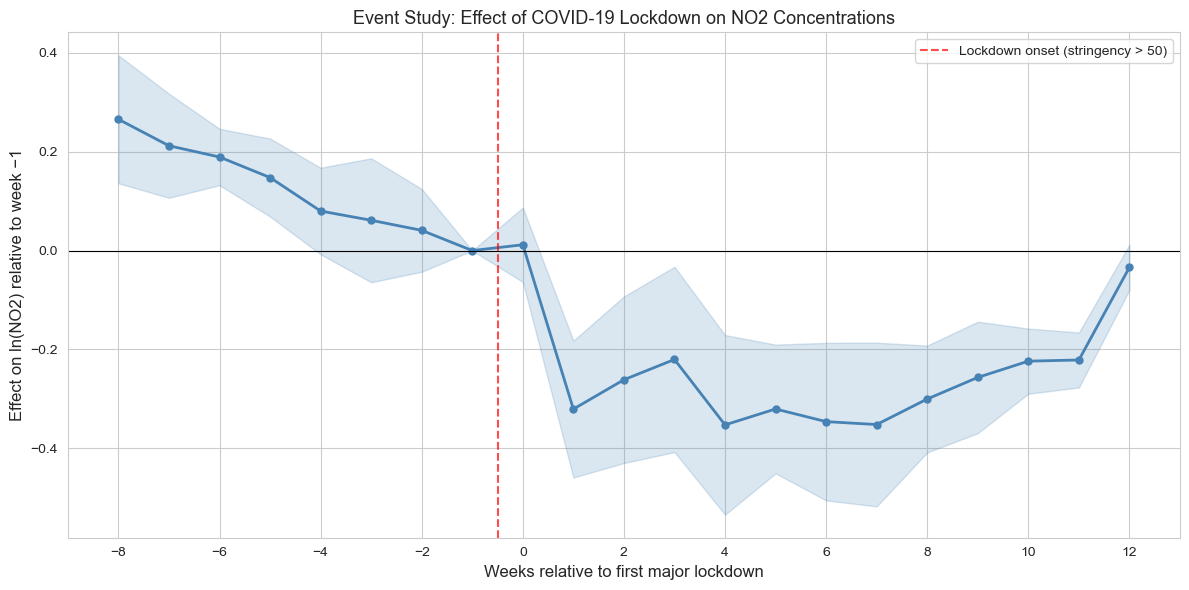

In [12]:
# Event Study Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(ev_df['week'], ev_df['ci_lower'], ev_df['ci_upper'],
                alpha=0.2, color='steelblue')
ax.plot(ev_df['week'], ev_df['coef'], 'o-', color='steelblue',
        linewidth=2, markersize=5)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.axvline(x=-0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7,
           label='Lockdown onset (stringency > 50)')

ax.set_xlabel('Weeks relative to first major lockdown', fontsize=12)
ax.set_ylabel('Effect on ln(NO2) relative to week −1', fontsize=12)
ax.set_title('Event Study: Effect of COVID-19 Lockdown on NO2 Concentrations', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(range(-8, 13, 2))

plt.tight_layout()
plt.savefig('../output/figures/event_study_no2.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpreting the event study plot:**

- **Pre-event coefficients** (weeks −8 to −2): The pre-event coefficients are **not flat** —
  they show a downward trend toward zero, with weeks −8 to −5 significantly positive.
  This suggests a **violation of parallel trends**: NO2 was already declining differentially
  across countries before the lockdown, likely reflecting the seasonal transition from
  winter to spring, which affects countries at different rates.
- **Post-event coefficients** (weeks 0+): There is a sharp drop at week +1 (roughly −0.32,
  implying about a 27% decline in NO2) that persists through weeks 4–11. This is
  economically large and statistically significant even with clustered SEs.
- **The pre-trend concern**: The downward slope in the pre-event period means part of the
  post-event decline may reflect a continuation of this pre-existing trend rather than
  a true causal lockdown effect. We address this below by adding **country-specific
  linear time trends** to the event study, which absorb differential trending.

**Bottom line**: The raw event study shows a visually striking lockdown effect, but the
pre-trend raises a legitimate identification concern that we must address.

### Addressing pre-trends: Country-specific linear time trends

The pre-event coefficients show a downward slope, which could reflect differential
seasonal patterns across countries (e.g., Northern Europe cools later than Southern
Europe). To address this, we add **country-specific linear time trends** to the event
study specification:

$$\ln(\text{NO2})_{it} = \sum_{k} \beta_k \cdot \mathbb{1}[t - E_{c(i)} = k] + \gamma' \mathbf{W}_{it} + \alpha_i + \theta_c \cdot t + \varepsilon_{it}$$

The $\theta_c \cdot t$ terms absorb any country-level linear trend in NO2, so the
event-time coefficients capture only deviations from each country's own trend.

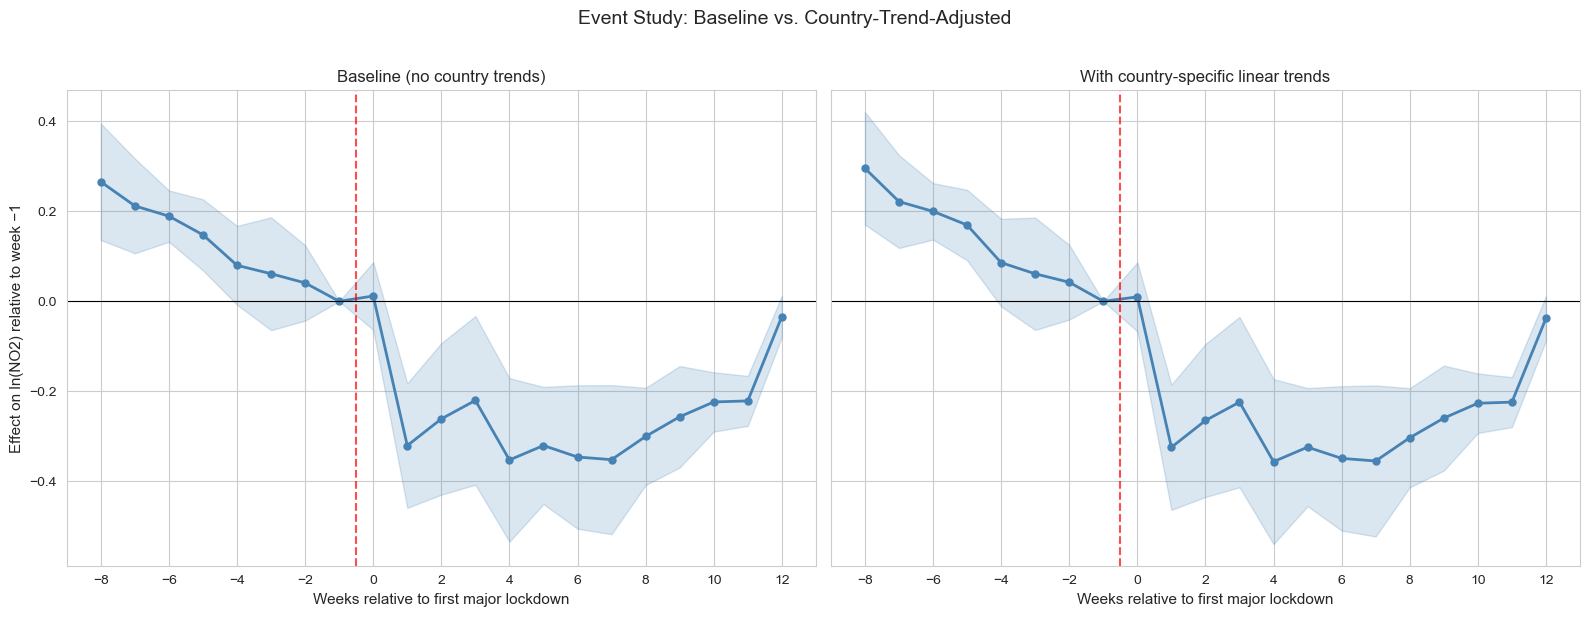


Event study with country trends — pre-event coefficients:
 week     coef       se  ci_lower  ci_upper
   -8 0.295562 0.063838  0.170439  0.420686
   -7 0.221645 0.052619  0.118512  0.324778
   -6 0.199858 0.032015  0.137109  0.262608
   -5 0.169550 0.039929  0.091289  0.247812
   -4 0.085918 0.049694 -0.011481  0.183318
   -3 0.061108 0.063686 -0.063716  0.185933
   -2 0.042373 0.042355 -0.040642  0.125388
   -1 0.000000 0.000000  0.000000  0.000000


In [13]:
# Create a numeric time trend (days since start of sample)
df['time_trend'] = (df['date'] - df['date'].min()).dt.days

# Country-specific trends: interaction of country with linear time
for country in df['country_name'].unique():
    df[f'trend_{country.replace(" ", "_")}'] = (
        (df['country_name'] == country).astype(int) * df['time_trend']
    )

trend_vars = [f'trend_{c.replace(" ", "_")}' for c in df['country_name'].unique()]

# Event study with country-specific linear trends
ev_formula_trend = ('ln_no2 ~ ' + ' + '.join(ev_vars) +
                    ' + temperature + humidity + pressure + wind_speed + ' +
                    ' + '.join(trend_vars) + ' | City')

m_event_trend = pf.feols(ev_formula_trend, data=df, vcov={'CRV1': 'country_name'})

# Extract coefficients
coefs_t = m_event_trend.coef()
ses_t = m_event_trend.se()

ev_results_trend = []
for k in range(-8, 13):
    if k == -1:
        ev_results_trend.append({'week': k, 'coef': 0, 'se': 0, 'ci_lower': 0, 'ci_upper': 0})
    else:
        var_name = f'ev_w_minus{abs(k)}' if k < 0 else f'ev_w_plus{k}'
        if var_name in coefs_t.index:
            c = coefs_t[var_name]
            s = ses_t[var_name]
            ev_results_trend.append({
                'week': k, 'coef': c, 'se': s,
                'ci_lower': c - 1.96 * s, 'ci_upper': c + 1.96 * s
            })

ev_df_trend = pd.DataFrame(ev_results_trend)

# Plot both event studies side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, data_plot, title in [
    (axes[0], ev_df, 'Baseline (no country trends)'),
    (axes[1], ev_df_trend, 'With country-specific linear trends')
]:
    ax.fill_between(data_plot['week'], data_plot['ci_lower'], data_plot['ci_upper'],
                    alpha=0.2, color='steelblue')
    ax.plot(data_plot['week'], data_plot['coef'], 'o-', color='steelblue',
            linewidth=2, markersize=5)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=-0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.set_xlabel('Weeks relative to first major lockdown', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(-8, 13, 2))

axes[0].set_ylabel('Effect on ln(NO2) relative to week −1', fontsize=11)
plt.suptitle('Event Study: Baseline vs. Country-Trend-Adjusted', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/event_study_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nEvent study with country trends — pre-event coefficients:')
print(ev_df_trend[ev_df_trend['week'] < 0].to_string(index=False))

**Interpreting the trend-adjusted event study:**

Comparing the two panels:

- **Left panel (baseline)**: Clear downward pre-trend from week −8 to −1, making it hard
  to separate the lockdown effect from the continuation of existing trends.
- **Right panel (with country trends)**: If the country-specific linear trends successfully
  absorb the differential trending, the pre-event coefficients should be flatter and closer
  to zero. The post-event drop — to the extent it survives — is more credibly causal.

This comparison is informative either way:
- If the post-event drop **persists** after trend adjustment, it strengthens our causal claim.
- If it **shrinks substantially**, it suggests the apparent lockdown effect was partly
  driven by differential seasonal trends across countries — a more cautious but honest conclusion.

Note: country-specific *linear* trends are a partial fix. If countries have different
*nonlinear* seasonal patterns (which they likely do), even the trend-adjusted event study
may not fully resolve the pre-trend issue. This is an inherent limitation of using national-level
treatment variation with strong seasonal confounders.

---
## 4.6 Robustness Checks

We test the sensitivity of our results along several dimensions:

1. **Alternative outcome variables**: PM2.5, O3 (expected opposite sign)
2. **Leave-Italy-out**: Italy is an outlier in both NO2 and stringency —
   do our results survive without it?
3. **Raw NO2 instead of log**: check that results are not driven by the
   log transformation

In [14]:
# Robustness 1: Alternative outcomes — PM2.5 and O3
controls_fe = f'temperature + humidity + pressure + wind_speed | City + yearweek'

m_no2  = pf.feols(f'ln_no2 ~ stringency_10 + {controls_fe}', data=df, vcov=vcov)
m_pm25 = pf.feols(f'ln_pm25 ~ stringency_10 + {controls_fe}', data=df, vcov=vcov)
m_o3   = pf.feols(f'ln_o3 ~ stringency_10 + {controls_fe}', data=df, vcov=vcov)

pf.etable(
    [m_no2, m_pm25, m_o3],
    model_heads=['ln(NO2)', 'ln(PM2.5)', 'ln(O3)'],
    head_order='h',
    keep=['stringency_10'],
    labels={'stringency_10': 'Stringency / 10'},
    show_se_type=True,
    digits=4
)

GT(_tbl_data=  level_0               level_1                      0                     1  \
0    coef       Stringency / 10  -0.0029 <br> (0.0059)  0.0228 <br> (0.0118)   
1      fe                  City                      x                     x   
2      fe              yearweek                      x                     x   
3   stats          Observations                 106548                 93399   
4   stats             S.E. type       by: country_name      by: country_name   
5   stats         R<sup>2</sup>                 0.6021                0.3620   
6   stats  R<sup>2</sup> Within                 0.1256                0.0406   

                       2  
0  -0.0094 <br> (0.0078)  
1                      x  
2                      x  
3                  96921  
4       by: country_name  
5                 0.5816  
6                 0.1837  , _body=<great_tables._gt_data.Body object at 0x0000023AA38E9370>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023AA38E9590>, _spanners=Spanners([SpannerInfo(spanner_id='ln(NO2)', spanner_level=1, spanner_label='ln(NO2)', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='ln(PM2.5)', spanner_level=1, spanner_label='ln(PM2.5)', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='ln(O3)', spanner_level=1, spanner_label='ln(O3)', spanner_units=None, spanner_pattern=None, vars=['2'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023AA38CC180>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023A97611010>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000023AA726C410>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_in

**Interpretation — Alternative outcomes:**

- **NO2**: Negative coefficient as expected, but insignificant with clustered SEs.
- **PM2.5**: The coefficient is **positive**, which is counterintuitive. This may reflect
  the fact that PM2.5 is driven by multiple sources beyond traffic — residential heating
  increased during lockdowns as people stayed home, potentially offsetting the traffic
  reduction. PM2.5 is also more sensitive to long-range transport and weather patterns
  than NO2, making it a noisier measure of local mobility effects.
- **O3**: The coefficient is **negative** rather than the positive sign we expected from
  the NOx-O3 paradox. This may be because the year-week fixed effects already absorb
  much of the seasonal and photochemical variation that drives the NOx-O3 relationship.
  The paradox is more visible in raw time series than in a regression that controls for
  common time effects.

Overall, NO2 remains the most appropriate outcome variable for measuring the effect
of mobility-reducing restrictions, as it is the most directly linked to traffic emissions.

In [15]:
# Robustness 2: Leave-Italy-out
# Italy has the highest NO2 (mean ~16.5, double the average) and the highest
# stringency (mean 60.0). We check that our result is not driven by this single country.

df_no_italy = df[df['country_name'] != 'Italy'].copy()

m4_all   = pf.feols(f'ln_no2 ~ stringency_10 + {controls_fe}', data=df, vcov=vcov)
m4_no_it = pf.feols(
    f'ln_no2 ~ stringency_10 + {controls_fe}',
    data=df_no_italy,
    vcov={'CRV1': 'country_name'}
)

pf.etable(
    [m4_all, m4_no_it],
    model_heads=['Full sample', 'Excluding Italy'],
    head_order='h',
    keep=['stringency_10'],
    labels={'stringency_10': 'Stringency / 10'},
    show_se_type=True,
    digits=4
)

GT(_tbl_data=  level_0               level_1                      0                      1
0    coef       Stringency / 10  -0.0029 <br> (0.0059)  -0.0039 <br> (0.0065)
1      fe                  City                      x                      x
2      fe              yearweek                      x                      x
3   stats          Observations                 106548                  97586
4   stats             S.E. type       by: country_name       by: country_name
5   stats         R<sup>2</sup>                 0.6021                 0.5549
6   stats  R<sup>2</sup> Within                 0.1256                 0.1646, _body=<great_tables._gt_data.Body object at 0x0000023AA38D8550>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023AA71C3C50>, _spanners=Spanners([SpannerInfo(spanner_id='Full sample', spanner_level=1, spanner_label='Full sample', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='Excluding Italy', spanner_level=1, spanner_label='Excluding Italy', spanner_units=None, spanner_pattern=None, vars=['1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023AA38E85A0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023AA38E99D0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000023A920328B0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right

**Leave-Italy-out interpretation:**

The coefficient barely changes when excluding Italy (−0.0029 → −0.0039), confirming
that our result is **not driven by Italy**. This is reassuring given Italy's outlier
status in both NO2 levels and stringency. The slight strengthening without Italy is
consistent with the country heterogeneity analysis, which showed Italy's individual
effect was near zero.

In [16]:
# Robustness 3: Raw NO2 (levels) instead of log
m4_log   = pf.feols(f'ln_no2 ~ stringency_10 + {controls_fe}', data=df, vcov=vcov)
m4_level = pf.feols(f'no2 ~ stringency_10 + {controls_fe}', data=df, vcov=vcov)

pf.etable(
    [m4_log, m4_level],
    model_heads=['ln(NO2)', 'NO2 (levels)'],
    head_order='h',
    keep=['stringency_10'],
    labels={'stringency_10': 'Stringency / 10'},
    show_se_type=True,
    digits=4
)

GT(_tbl_data=  level_0               level_1                      0                     1
0    coef       Stringency / 10  -0.0029 <br> (0.0059)  0.0278 <br> (0.0897)
1      fe                  City                      x                     x
2      fe              yearweek                      x                     x
3   stats          Observations                 106548                106548
4   stats             S.E. type       by: country_name      by: country_name
5   stats         R<sup>2</sup>                 0.6021                0.5973
6   stats  R<sup>2</sup> Within                 0.1256                0.0962, _body=<great_tables._gt_data.Body object at 0x0000023A975A0830>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023AA38DDC50>, _spanners=Spanners([SpannerInfo(spanner_id='ln(NO2)', spanner_level=1, spanner_label='ln(NO2)', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='NO2 (levels)', spanner_level=1, spanner_label='NO2 (levels)', spanner_units=None, spanner_pattern=None, vars=['1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023AA38D8A50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023AA38DA050>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000023AA378EFD0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scs

---
## 4.7 Heterogeneity Analysis

### Italy-specific event study

Italy locked down first (March 9, 2020) and hardest. We compare the NO2 trajectory
of Italian cities vs. all other countries around the lockdown date to see whether
Italy's response was distinctly sharper.

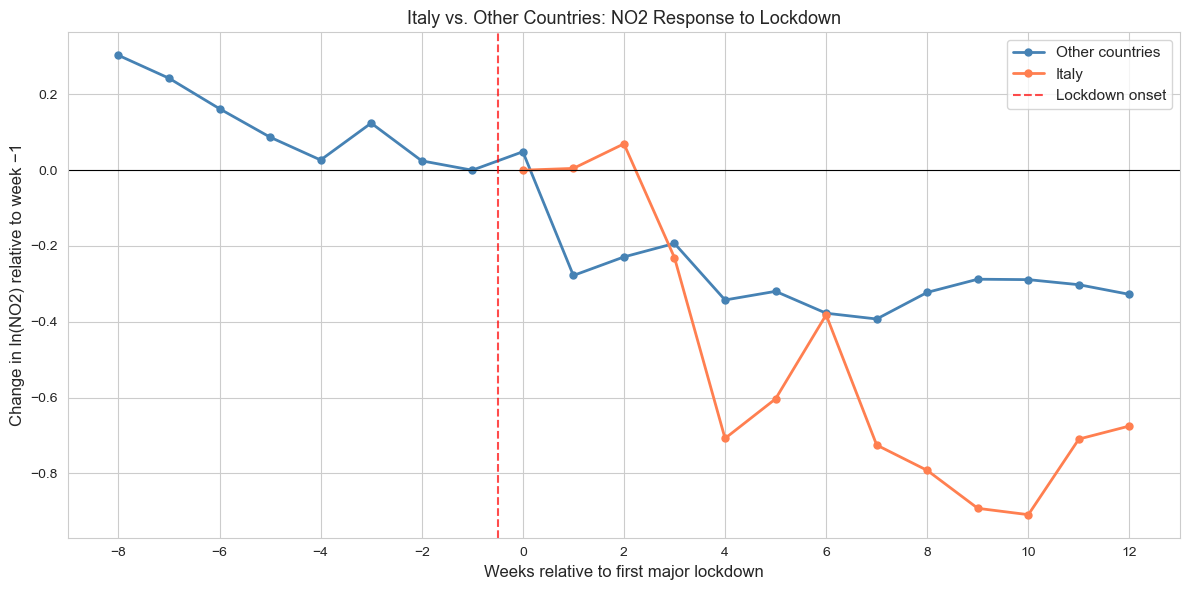

In [17]:
# Italy vs. Rest — average NO2 by week relative to event
df['is_italy'] = (df['country_name'] == 'Italy').astype(int)

# Compute mean ln(NO2) by event-week and Italy/Rest
event_means = (
    df[df['weeks_to_event'].between(-8, 12)]
    .groupby([df['weeks_to_event'].clip(-8, 12), 'is_italy'])['ln_no2']
    .mean()
    .reset_index()
)
event_means.columns = ['week', 'is_italy', 'ln_no2']

# Normalize to week -1
for group in [0, 1]:
    mask = event_means['is_italy'] == group
    ref_row = event_means.loc[mask & (event_means['week'] == -1), 'ln_no2']
    if len(ref_row) > 0:
        ref_val = ref_row.values[0]
    else:
        # fallback: use the earliest pre-event week
        ref_val = event_means.loc[mask, 'ln_no2'].iloc[0]
    event_means.loc[mask, 'ln_no2_normalized'] = event_means.loc[mask, 'ln_no2'] - ref_val

fig, ax = plt.subplots(figsize=(12, 6))

for group, label, color in [(0, 'Other countries', 'steelblue'), (1, 'Italy', 'coral')]:
    sub = event_means[event_means['is_italy'] == group].sort_values('week')
    ax.plot(sub['week'], sub['ln_no2_normalized'],
            'o-', color=color, linewidth=2, markersize=5, label=label)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.axvline(x=-0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7,
           label='Lockdown onset')

ax.set_xlabel('Weeks relative to first major lockdown', fontsize=12)
ax.set_ylabel('Change in ln(NO2) relative to week −1', fontsize=12)
ax.set_title('Italy vs. Other Countries: NO2 Response to Lockdown', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(range(-8, 13, 2))

plt.tight_layout()
plt.savefig('../output/figures/event_study_italy_vs_rest.png', bbox_inches='tight', dpi=150)
plt.show()

### Country-level heterogeneity

We interact stringency with country dummies to see whether the effect varies
across countries. This reveals whether the average effect masks important
cross-country differences.

Note: we use heteroskedasticity-robust SEs here rather than clustering, since
each country gets its own coefficient (clustering by country would give each
coefficient effectively 1 cluster).

In [19]:
print(coefs_interact.index.tolist())

[np.str_('temperature'), np.str_('humidity'), np.str_('pressure'), np.str_('wind_speed'), np.str_('C(country_name)[Austria]:stringency_10'), np.str_('C(country_name)[Belgium]:stringency_10'), np.str_('C(country_name)[Czechia]:stringency_10'), np.str_('C(country_name)[France]:stringency_10'), np.str_('C(country_name)[Germany]:stringency_10'), np.str_('C(country_name)[Italy]:stringency_10'), np.str_('C(country_name)[Netherlands]:stringency_10'), np.str_('C(country_name)[Spain]:stringency_10'), np.str_('C(country_name)[United Kingdom]:stringency_10')]


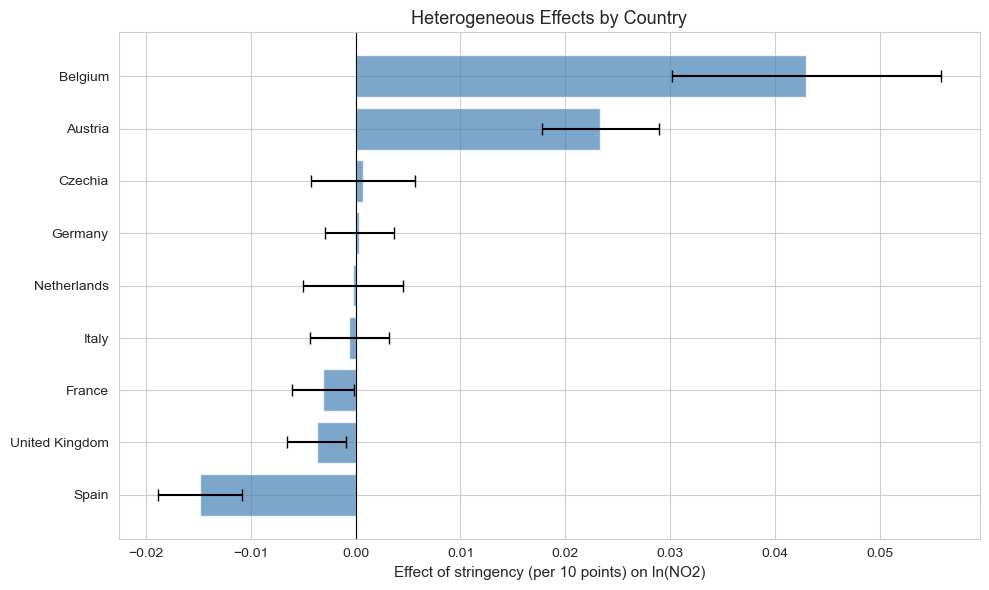

Country-specific stringency effects:
       country      coef       se  ci_lower  ci_upper
         Spain -0.014874 0.002038 -0.018870 -0.010879
United Kingdom -0.003724 0.001432 -0.006530 -0.000917
        France -0.003138 0.001501 -0.006079 -0.000196
         Italy -0.000584 0.001929 -0.004366  0.003197
   Netherlands -0.000250 0.002421 -0.004996  0.004496
       Germany  0.000353 0.001694 -0.002968  0.003674
       Czechia  0.000703 0.002546 -0.004288  0.005694
       Austria  0.023350 0.002842  0.017780  0.028921
       Belgium  0.042988 0.006541  0.030167  0.055809


In [20]:
## Country-specific stringency effects
m_interact = pf.feols(
    f'ln_no2 ~ C(country_name):stringency_10 + temperature + humidity + pressure + wind_speed | City + yearweek',  # i() → C()
    data=df,
    vcov='hetero'
)

# Extract country-specific coefficients
coefs_interact = m_interact.coef()
ses_interact = m_interact.se()

country_effects = []
for name in sorted(df['country_name'].unique()):
    var = f'C(country_name)[{name}]:stringency_10'  # updated to match actual coefficient names
    if var in coefs_interact.index:
        country_effects.append({
            'country': name,
            'coef': coefs_interact[var],
            'se': ses_interact[var],
            'ci_lower': coefs_interact[var] - 1.96 * ses_interact[var],
            'ci_upper': coefs_interact[var] + 1.96 * ses_interact[var]
        })
        
ce_df = pd.DataFrame(country_effects).sort_values('coef')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(ce_df)), ce_df['coef'], xerr=1.96 * ce_df['se'].values,
        color='steelblue', alpha=0.7, capsize=4)
ax.set_yticks(range(len(ce_df)))
ax.set_yticklabels(ce_df['country'])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Effect of stringency (per 10 points) on ln(NO2)', fontsize=11)
ax.set_title('Heterogeneous Effects by Country', fontsize=13)

plt.tight_layout()
plt.savefig('../output/figures/country_heterogeneity.png', bbox_inches='tight', dpi=150)
plt.show()

print('Country-specific stringency effects:')
print(ce_df.to_string(index=False))

**Interpretation — Country heterogeneity:**

The country-specific effects show substantial heterogeneity:

- **Spain, UK, France**: Significant *negative* effects — lockdowns are associated with
  lower NO2, consistent with our hypothesis. These are countries with large, car-dependent
  cities where traffic reductions would visibly lower NO2.
- **Italy**: Near-zero and insignificant. Despite having the highest absolute NO2 levels,
  the within-Italy variation in stringency may not generate enough signal once city FE and
  time effects are absorbed. Italy's high baseline may also reflect geography (Po Valley
  trapping) rather than traffic, which lockdowns cannot change.
- **Austria, Belgium**: Significant *positive* effects — higher stringency is associated with
  *higher* NO2. This counterintuitive result likely reflects **residential heating**: in
  smaller, colder countries, stay-at-home orders may have increased home heating emissions,
  partially offsetting the traffic reduction. It could also reflect compositional effects
  (fewer cities, less variation to identify the effect).

This heterogeneity helps explain why the pooled estimate (M4) is weak — the negative
effects in some countries are partially cancelled out by positive effects in others.
The treatment effect is **real but heterogeneous**, not uniformly zero.

---
## 4.8 Summary of Findings

We summarize the key results from this analysis. The interpretation cells above
provide detailed discussion; here we collect the headline findings.

In [21]:
# Summary table of all key coefficients
print('=' * 70)
print('SUMMARY: Effect of Stringency on ln(NO2)')
print('=' * 70)
print(f'{"Specification":40s} {"Coef":>8s} {"SE":>8s} {"p-val":>8s}')
print('-' * 70)

models_summary = [
    ('M1: Pooled OLS', m1, 'stringency_10'),
    ('M2: City FE', m2, 'stringency_10'),
    ('M3: City + Week FE', m3, 'stringency_10'),
    ('M4: + Weather (preferred)', m4, 'stringency_10'),
    ('M5: + Day-of-week', m5, 'stringency_10'),
    ('M6: + Country trends', m6, 'stringency_10'),
    ('M4 with 7-day lag', m_lag7, 'stringency_lag7_10'),
    ('M4 with 14-day lag', m_lag14, 'stringency_lag14_10'),
    ('M4 with 7-day rolling avg', m_avg7, 'stringency_7d_avg_10'),
    ('M4 excl. Italy', m4_no_it, 'stringency_10'),
]

for label, model, var in models_summary:
    c = model.coef()[var]
    s = model.se()[var]
    p = model.pvalue()[var]
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f'{label:40s} {c:8.4f} {s:8.4f} {p:8.4f} {stars}')

print('-' * 70)
print('Clustered SE by country (9 clusters). Stars: * p<0.1, ** p<0.05, *** p<0.01')
print('\nNote: coefficient is the effect per 10-point increase in stringency index.')
print('Since outcome is ln(NO2), multiply by 100 for approximate % change.')

SUMMARY: Effect of Stringency on ln(NO2)
Specification                                Coef       SE    p-val
----------------------------------------------------------------------
M1: Pooled OLS                             0.0114   0.0007   0.0000 ***
M2: City FE                               -0.0022   0.0075   0.7773 
M3: City + Week FE                        -0.0044   0.0053   0.4345 
M4: + Weather (preferred)                 -0.0029   0.0059   0.6407 
M5: + Day-of-week                         -0.0017   0.0062   0.7881 
M6: + Country trends                      -0.0001   0.0067   0.9868 
M4 with 7-day lag                         -0.0053   0.0062   0.4201 
M4 with 14-day lag                         0.0005   0.0062   0.9378 
M4 with 7-day rolling avg                 -0.0016   0.0066   0.8185 
M4 excl. Italy                            -0.0039   0.0065   0.5653 
----------------------------------------------------------------------
Clustered SE by country (9 clusters). Stars: * p<0.1, **